# Regress trace element concentrations vs growth and environment

Author: **Niels J. de Winter** (*n.j.de.winter@vu.nl*)<br>
Assistant Professor Vrije Universiteit Amsterdam

In [31]:
# Load necessary libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import linregress
import numpy as np
import statsmodels.api as sm

## Example: One specimen

In [3]:
# Load one file from the folder
file_path = "TE_data_with_GR_T_S/G652_sub_peakid.csv"  # Test for one specimen
data = pd.read_csv(file_path)
data.head()

,depth,proxy_filtered,time,Xpos,Ypos,Ca43,23Na/43Ca,25Mg/43Ca,55Mn/43Ca,88Sr/43Ca,...,timing_info_centered,interval_growth_rate,interval_growth_rate_centered,interval_total_growth,interval_total_growth_centered,interval_total_time_days,T,T_std,S,S_std
0,0.426825,0.131868,62.87978,71074.74930,46513.67210,1650.108907,831.612523,6.181713,2.065418,0.131868,...,2022-10-25 10:00:00,19.748685,31.612585,914.713074,1464.221264,46.317669,5.843,0.008,25.485,0.03
1,0.853650,0.108273,62.98893,71074.59489,46513.27419,1850.136910,694.830082,8.459364,1.591473,0.108273,...,2022-10-25 09:30:29.401482430,19.748685,31.612585,914.713074,1464.221264,46.317669,5.843,0.008,25.485,0.03
2,1.280475,0.000000,63.09807,71074.44047,46512.87627,1500.090005,1055.629092,12.315843,2.279010,0.000000,...,2022-10-25 09:00:58.802964860,19.748685,31.612585,914.713074,1464.221264,46.317669,5.843,0.008,25.485,0.03
3,1.707300,0.139467,63.20722,71074.28606,46512.47836,1600.102407,936.795248,32.690322,2.117207,0.139467,...,2022-10-25 08:31:28.204447290,19.748685,31.612585,914.713074,1464.221264,46.317669,5.843,0.008,25.485,0.03
4,2.134126,0.065934,63.31641,71074.13164,46512.08044,1650.108907,889.753685,18.545361,2.128978,0.065934,...,2022-10-25 08:01:57.601781419,19.748685,31.612585,914.713074,1464.221264,46.317669,5.872,0.025,25.39,0.073


### Plot Sr/Ca vs temperature

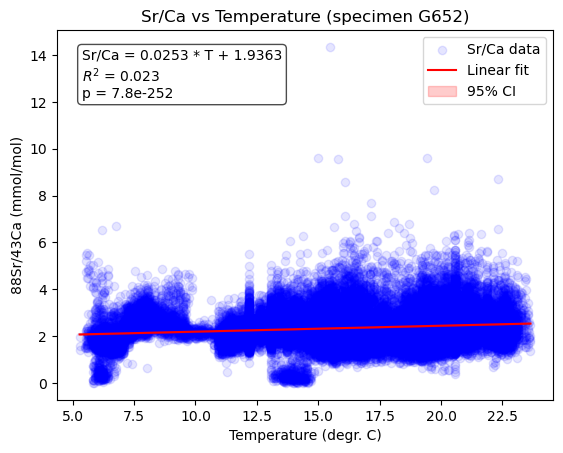

In [4]:
# Convert 'T' and 'T_std' columns to numeric, coerce errors to NaN
data['T'] = pd.to_numeric(data['T'], errors='coerce')
data['T_std'] = pd.to_numeric(data['T_std'], errors='coerce')

# Regression of Sr/Ca vs Temperature
# Remove rows with NaN in relevant columns
mask_temp = data[['T', '88Sr/43Ca']].notnull().all(axis=1)
x_temp = data.loc[mask_temp, 'T']
y_temp = data.loc[mask_temp, '88Sr/43Ca']

# Linear regression
slope_temp, intercept_temp, r_value_temp, p_value_temp, std_err_temp = linregress(x_temp, y_temp)
x_fit_temp = np.linspace(x_temp.min(), x_temp.max(), 200)
y_fit_temp = intercept_temp + slope_temp * x_fit_temp

# Calculate uncertainty envelope (95% confidence interval)
y_pred_temp = intercept_temp + slope_temp * x_temp
n_temp = len(x_temp)
t_val_temp = 1.96  # Approximate for large n, 95% CI
s_err_temp = np.sqrt(np.sum((y_temp - y_pred_temp) ** 2) / (n_temp - 2))
conf_temp = t_val_temp * s_err_temp * np.sqrt(1/n_temp + (x_fit_temp - np.mean(x_temp))**2 / np.sum((x_temp - np.mean(x_temp))**2))

# Plot Sr/Ca vs Temperature with uncertainties and regression fit in the same plot
plt.scatter(x_temp, y_temp, color='blue', alpha=0.1, label='Sr/Ca data')
plt.plot(x_fit_temp, y_fit_temp, color='red', label='Linear fit')
plt.fill_between(x_fit_temp, y_fit_temp - conf_temp, y_fit_temp + conf_temp, color='red', alpha=0.2, label='95% CI')
plt.xlabel('Temperature (degr. C)')
plt.ylabel('88Sr/43Ca (mmol/mol)')
plt.title('Sr/Ca vs Temperature (specimen G652)')

# Add regression statistics to the plot
eqn = f'Sr/Ca = {slope_temp:.4f} * T + {intercept_temp:.4f}'
stats = f'$R^2$ = {r_value_temp**2:.3f}\np = {p_value_temp:.1e}'
plt.text(0.05, 0.95, eqn + '\n' + stats, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.legend()
plt.show()

### Plot Sr/Ca vs growth rate

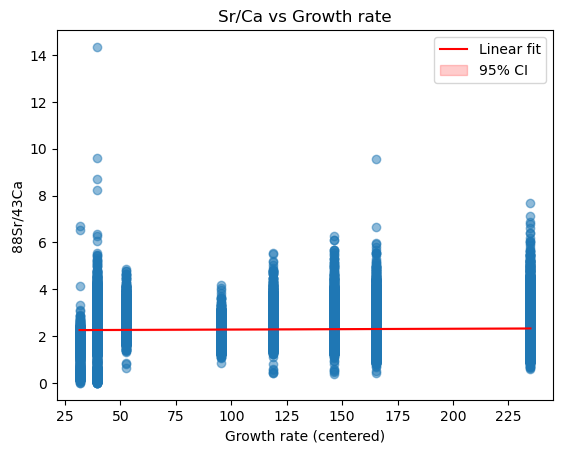

In [5]:
# Remove rows with NaN in relevant columns
mask = data[['interval_growth_rate_centered', '88Sr/43Ca']].notnull().all(axis=1)
x = data.loc[mask, 'interval_growth_rate_centered']
y = data.loc[mask, '88Sr/43Ca']

# Scatter plot
plt.plot(x, y, 'o', alpha=0.5)

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = intercept + slope * x_fit

# Calculate uncertainty envelope (95% confidence interval)
y_pred = intercept + slope * x
n = len(x)
t_val = 1.96  # Approximate for large n, 95% CI
s_err = np.sqrt(np.sum((y - y_pred) ** 2) / (n - 2))
conf = t_val * s_err * np.sqrt(1/n + (x_fit - np.mean(x))**2 / np.sum((x - np.mean(x))**2))

plt.plot(x_fit, y_fit, color='red', label='Linear fit')
plt.fill_between(x_fit, y_fit - conf, y_fit + conf, color='red', alpha=0.2, label='95% CI')

plt.xlabel('Growth rate (centered)')
plt.ylabel('88Sr/43Ca')
plt.title('Sr/Ca vs Growth rate')
plt.legend()
plt.show()

## Combine data from all specimens

### Read data from all specimens

In [6]:
# Load all files from the folder
folder_path = "TE_data_with_GR_T_S/"
all_data = pd.DataFrame()
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        # Read each file
        file_data = pd.read_csv(
            os.path.join(folder_path, file),
            dtype={'T': "O", 'T_std': "O", 'S' : "O", 'S_std': "O"},
            index_col=0
        )
        # Add a column for the specimen name
        file_data['specimen'] = file.split('_')[0]  # Specimen name is the first part of the filename
        # Concatenate into a single DataFrame
        all_data = pd.concat([all_data, file_data], ignore_index=True)

# Display the first few rows of the combined data
all_data.head()

,proxy_filtered,time,Xpos,Ypos,Ca43,23Na/43Ca,25Mg/43Ca,43Ca/43Ca,55Mn/43Ca,88Sr/43Ca,...,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,0.013676,62.33211,30944.10620,80703.27530,6301.588000,199.059248,1.253571,1000.0,0.306491,0.013676,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.000000,62.44125,30944.46978,80703.01737,5301.123838,235.482235,3.406310,1000.0,0.347474,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.019326,62.55040,30944.83337,80702.75945,4600.846556,284.331679,1.771388,1000.0,0.380053,0.019326,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.037763,62.65955,30945.19695,80702.50152,5751.322804,221.307763,3.115197,1000.0,0.348871,0.037763,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.013795,62.76871,30945.56053,80702.24359,6251.562891,205.558351,1.264443,1000.0,0.242893,0.013795,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Clean combined dataframe

In [7]:
# Remove all unnamed columns
all_data = all_data.loc[:, ~all_data.columns.str.contains('^Unnamed')]

# Convert temperature and salinity columns to numeric, coerce errors to NaN
all_data['T'] = pd.to_numeric(all_data['T'], errors='coerce')
all_data['T_std'] = pd.to_numeric(all_data['T_std'], errors='coerce')
all_data['S'] = pd.to_numeric(all_data['S'], errors='coerce')
all_data['S_std'] = pd.to_numeric(all_data['S_std'], errors='coerce')

# print dtypes of all columns
print(all_data.dtypes)

proxy_filtered                    float64
time                              float64
Xpos                              float64
Ypos                              float64
Ca43                              float64
23Na/43Ca                         float64
25Mg/43Ca                         float64
43Ca/43Ca                         float64
55Mn/43Ca                         float64
88Sr/43Ca                         float64
138Ba/43Ca                        float64
peak                               object
timing_info                        object
timing_info_centered               object
interval_growth_rate              float64
interval_growth_rate_centered     float64
interval_total_growth             float64
interval_total_growth_centered    float64
interval_total_time_days          float64
T                                 float64
T_std                             float64
S                                 float64
S_std                             float64
specimen                          

### Summarize elemental, growth and environmental values per specimen and per interval

In [8]:
# Summarize elemental, growth and environmental values per specimen and per interval, 
data_summary = all_data.groupby(['specimen', 'peak']).agg(
    NaCa_mean=('23Na/43Ca', 'mean'),
    NaCa_sd=('23Na/43Ca', 'std'),
    MgCa_mean=('25Mg/43Ca', 'mean'),
    MgCa_sd=('25Mg/43Ca', 'std'),
    MnCa_mean=('55Mn/43Ca', 'mean'),
    MnCa_sd=('55Mn/43Ca', 'std'),
    SrCa_mean=('88Sr/43Ca', 'mean'),
    SrCa_sd=('88Sr/43Ca', 'std'),
    BaCa_mean=('138Ba/43Ca', 'mean'),
    BaCa_sd=('138Ba/43Ca', 'std'),
    growth_mean=('interval_growth_rate_centered', 'mean'),
    growth_sd=('interval_growth_rate_centered', 'std'),
    T_mean=('T', 'mean'),
    T_sd=('T', 'std'),
    S_mean=('S', 'mean'),
    S_sd=('S', 'std'),
    N=('23Na/43Ca', 'count')
).reset_index()

# Display the first few rows of the summarized data
data_summary.head()

,specimen,peak,NaCa_mean,NaCa_sd,MgCa_mean,MgCa_sd,MnCa_mean,MnCa_sd,SrCa_mean,SrCa_sd,BaCa_mean,BaCa_sd,growth_mean,growth_sd,T_mean,T_sd,S_mean,S_sd,N
0,B255,interval 0,44.567746,56.508452,1.160976,0.594605,0.034916,0.091594,1.158004,0.383664,0.001420,0.002077,21.405031,0.0,9.684376,2.533393,26.898304,1.767991,2143
1,B255,interval 1,26.273800,3.072668,0.719110,0.110520,0.006407,0.001172,1.278613,0.176885,0.001153,0.000252,49.726902,0.0,12.460874,0.922967,29.399738,1.094747,1963
2,B255,interval 2,25.151038,4.199140,0.962705,0.172410,0.010096,0.001694,1.889094,0.367165,0.002411,0.000558,149.865296,0.0,15.499778,1.119769,30.428576,0.485214,5226
3,B255,interval 3,23.462455,4.528163,0.967798,0.209171,0.010317,0.001871,2.038598,0.481682,0.003512,0.000961,179.218754,0.0,17.332671,1.919938,29.540670,0.748321,9455
4,B255,interval 4,22.258818,5.393297,1.157388,0.289976,0.008324,0.001733,2.167418,0.592524,0.005096,0.001246,89.825457,0.0,19.583781,0.389001,30.005489,0.691253,4311


### Export data summary

In [9]:
data_summary.to_csv("All_data_summary.csv", index=False)

## Exploratory data analysis

### Plot Pearson correlation matrix

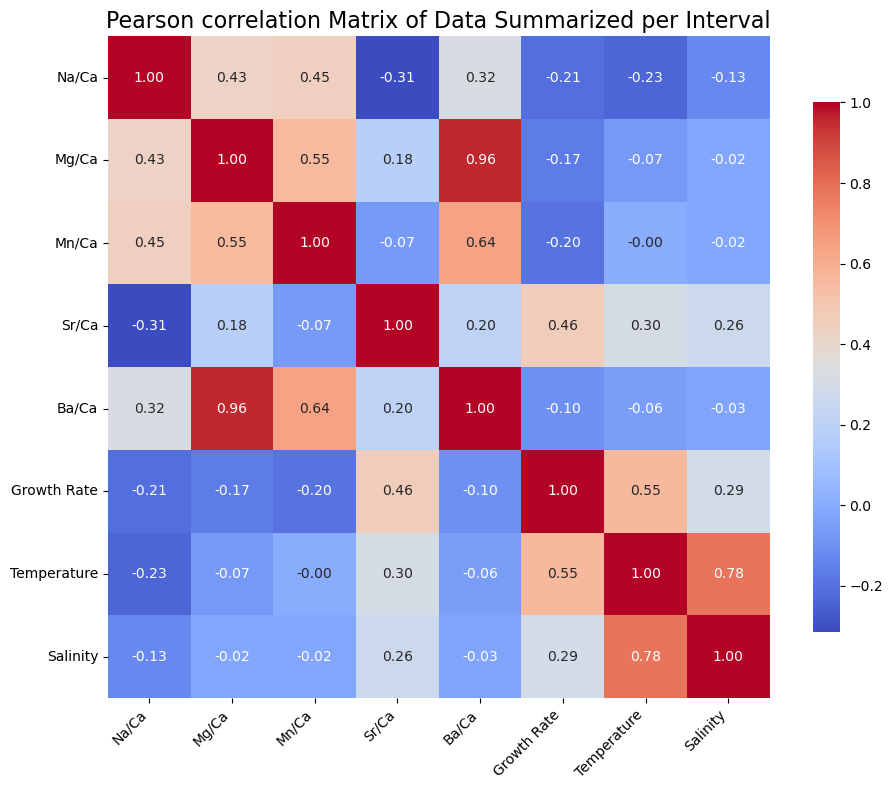

In [10]:
# Plot correlation matrix for data_summary
# Mapping actual column names → display names
predictor_display_names = {
    'T_mean': 'Temperature',
    'S_mean': 'Salinity',
    'growth_mean': 'Growth Rate'
}

response_display_names = {
    'NaCa_mean': 'Na/Ca',
    'MgCa_mean': 'Mg/Ca',
    'MnCa_mean': 'Mn/Ca',
    'SrCa_mean': 'Sr/Ca',
    'BaCa_mean': 'Ba/Ca'
}

# Combine all display name mappings
all_display_names = {**predictor_display_names, **response_display_names}

# Isolate the relevant columns for the correlation matrix
correlation_columns = [
    'NaCa_mean',
    'MgCa_mean',
    'MnCa_mean',
    'SrCa_mean',
    'BaCa_mean',
    'growth_mean',
    'T_mean',
    'S_mean',
]
data_summary_trim = data_summary[correlation_columns]

# Compute correlation and apply renamed labels
corr = data_summary_trim.corr()
corr.rename(index=all_display_names, columns=all_display_names, inplace=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Pearson correlation Matrix of Data Summarized per Interval', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Plot Spearman correlation matrix

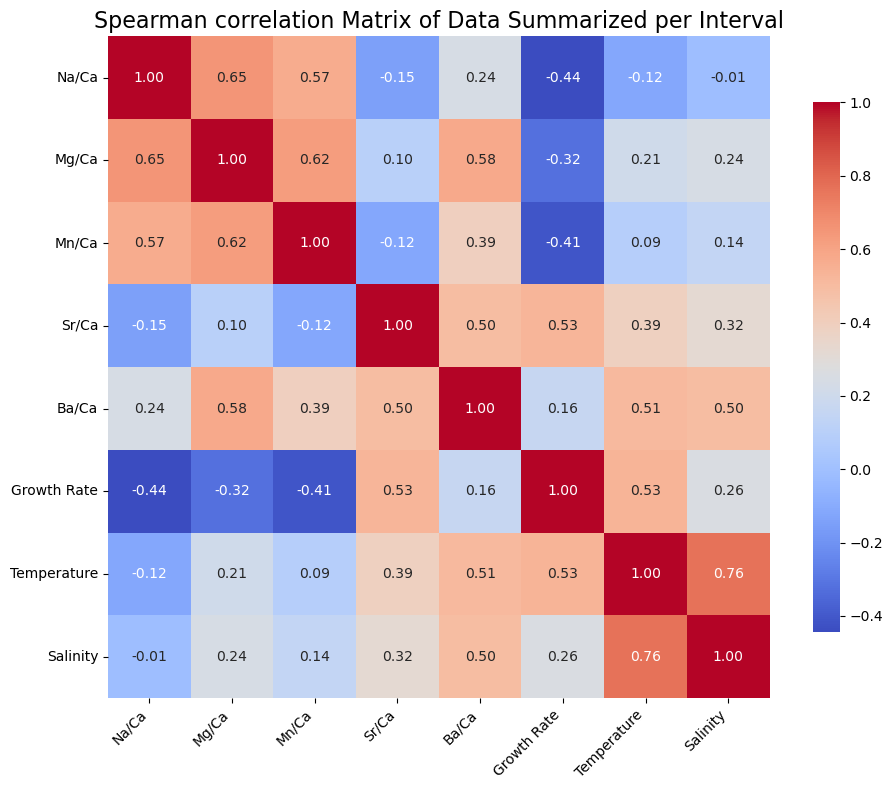

In [12]:
# Plot correlation matrix for data_summary
# Mapping actual column names → display names
predictor_display_names = {
    'T_mean': 'Temperature',
    'S_mean': 'Salinity',
    'growth_mean': 'Growth Rate'
}

response_display_names = {
    'NaCa_mean': 'Na/Ca',
    'MgCa_mean': 'Mg/Ca',
    'MnCa_mean': 'Mn/Ca',
    'SrCa_mean': 'Sr/Ca',
    'BaCa_mean': 'Ba/Ca'
}

# Combine all display name mappings
all_display_names = {**predictor_display_names, **response_display_names}

# Isolate the relevant columns for the correlation matrix
correlation_columns = [
    'NaCa_mean',
    'MgCa_mean',
    'MnCa_mean',
    'SrCa_mean',
    'BaCa_mean',
    'growth_mean',
    'T_mean',
    'S_mean',
]
data_summary_trim = data_summary[correlation_columns]

# Compute correlation and apply renamed labels
corr_spearman = data_summary_trim.corr(method = 'spearman')
corr_spearman.rename(index=all_display_names, columns=all_display_names, inplace=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Spearman correlation Matrix of Data Summarized per Interval', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Plot Pairwise scatterplots

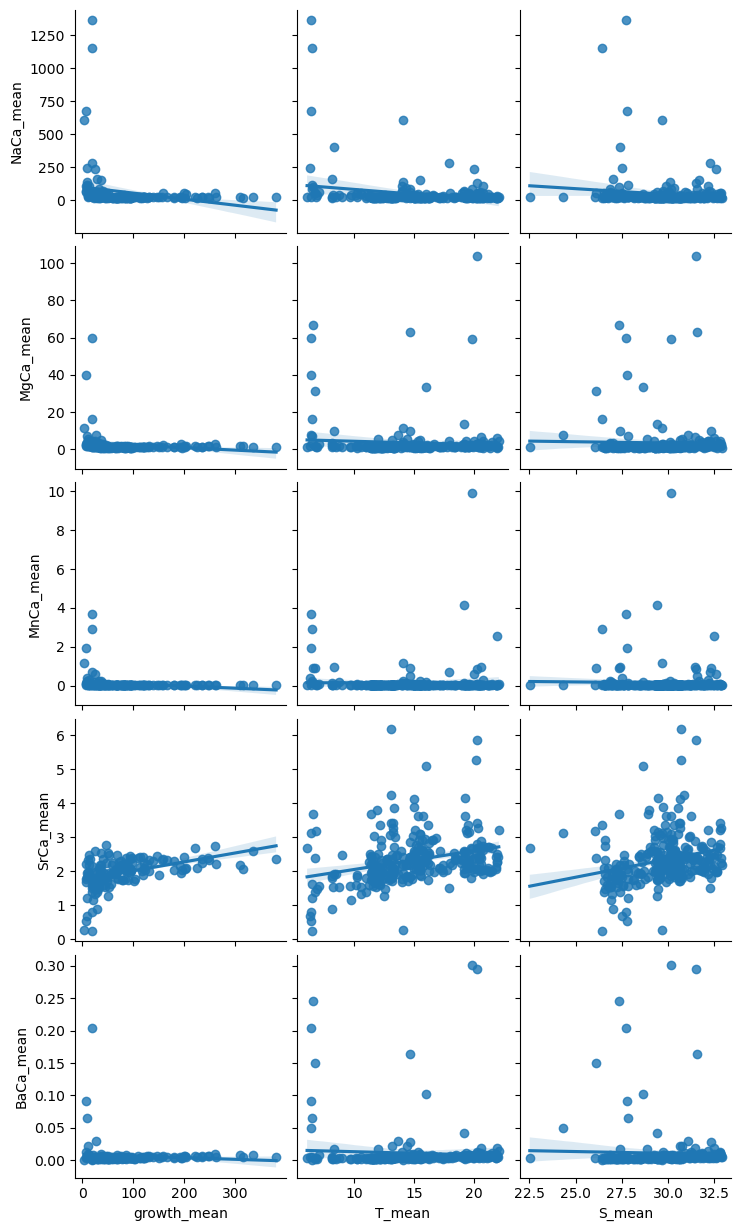

In [12]:
sns.pairplot(data_summary, x_vars=['growth_mean', 'T_mean', 'S_mean'],
                   y_vars=['NaCa_mean', 'MgCa_mean', 'MnCa_mean', 'SrCa_mean', 'BaCa_mean'],
                   kind='reg')

### Pairwise scatter plots with errors and by-specimen statistics

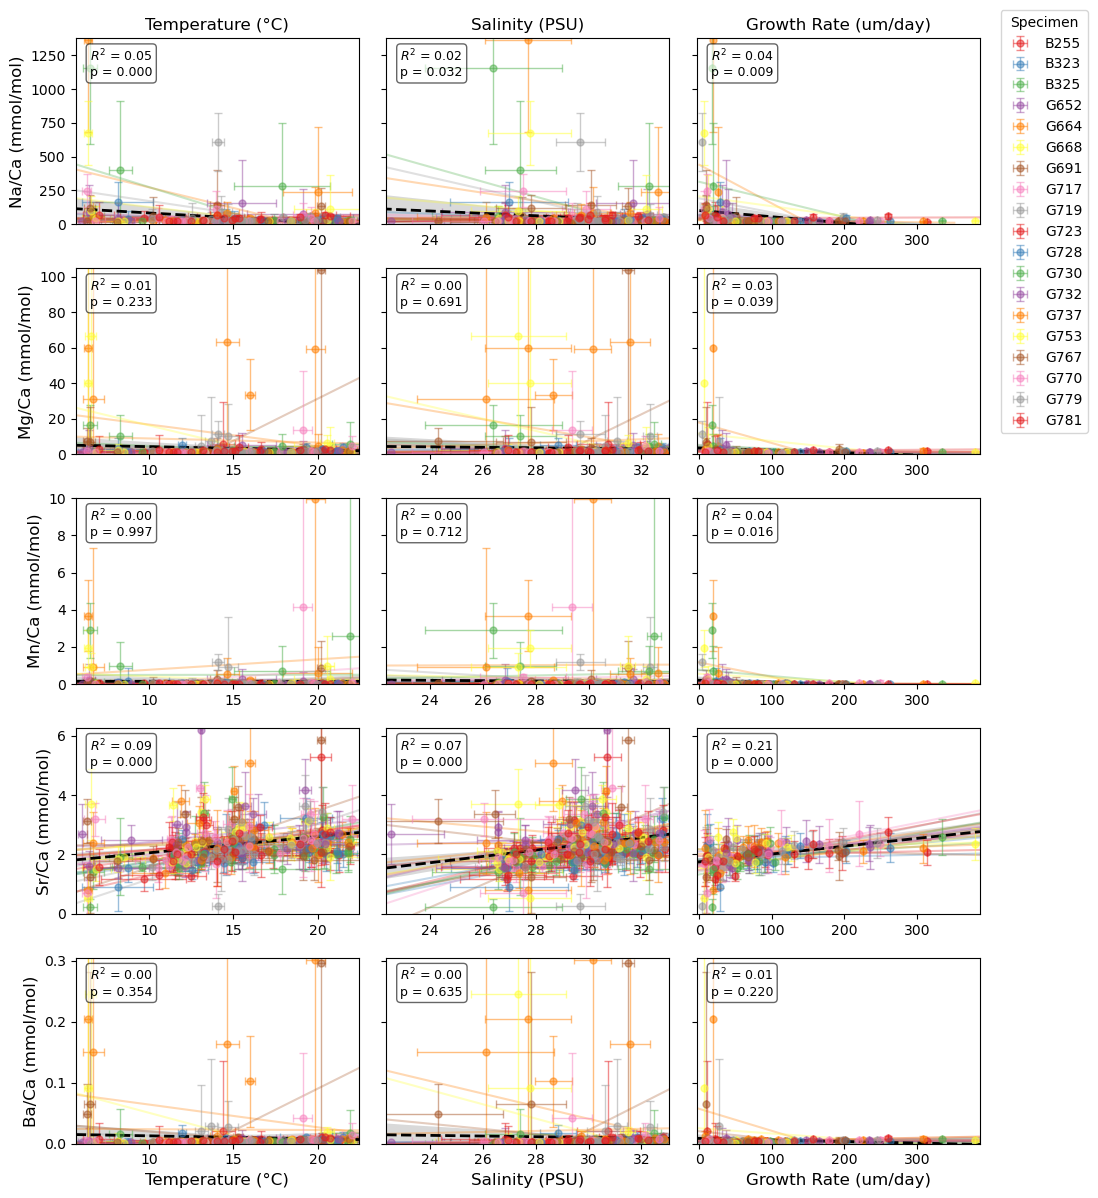

In [42]:
# Mapping actual column names → display names
predictor_display_names = {
    'T_mean': 'Temperature (°C)',
    'S_mean': 'Salinity (PSU)',
    'growth_mean': 'Growth Rate (um/day)'
}

response_display_names = {
    'NaCa_mean': 'Na/Ca (mmol/mol)',
    'MgCa_mean': 'Mg/Ca (mmol/mol)',
    'MnCa_mean': 'Mn/Ca (mmol/mol)',
    'SrCa_mean': 'Sr/Ca (mmol/mol)',
    'BaCa_mean': 'Ba/Ca (mmol/mol)'
}

predictor_names = {
    'T_mean': 'T_sd',
    'S_mean': 'S_sd',
    'growth_mean': 'growth_sd'
}

response_names = {
    'NaCa_mean': 'NaCa_sd',
    'MgCa_mean': 'MgCa_sd',
    'MnCa_mean': 'MnCa_sd',
    'SrCa_mean': 'SrCa_sd',
    'BaCa_mean': 'BaCa_sd'
}

# Prepare data for pairwise scatter plots
predictors = list(predictor_names.keys())
responses = list(response_names.keys())

# Assign unique colors to each specimen
specimens = data_summary['specimen'].unique()
palette = sns.color_palette("Set1", n_colors=len(specimens))
specimen_colors = dict(zip(specimens, palette))

# Store regression stats
global_stats_lin_all = {}      # global regression stats
specimen_stats_lin_all = {}    # optional, not plotted

# Initialize the figure and axes for pairwise scatter plots
fig, axs = plt.subplots(len(responses), len(predictors), figsize=(10, 12), sharex='col', sharey='row')

for i, response in enumerate(responses):
    for j, predictor in enumerate(predictors):
        ax = axs[i, j]
        for specimen in specimens:
            df_subset = data_summary[data_summary['specimen'] == specimen]
            # Plot regression line per specimen
            sns.regplot(
                x=predictor,
                y=response,
                data=df_subset,
                scatter=False,
                ax=ax,
                ci=None,
                color=specimen_colors[specimen],
                line_kws={"lw": 1.5, "alpha": 0.3},
                truncate=False
            )

            # Compute and store specimen-specific stats
            df_regs = df_subset.dropna(subset=[predictor, response])
            Xs = sm.add_constant(df_regs[predictor])
            ys = df_regs[response]
            if len(Xs) > 2:
                model_s = sm.OLS(ys, Xs).fit()
                specimen_stats_lin_all[(response, predictor, specimen)] = {
                    'r2': model_s.rsquared,
                    'p': model_s.pvalues[predictor]
                }
            else:
                specimen_stats_lin_all[(response, predictor, specimen)] = {
                    'r2': np.nan,
                    'p': np.nan
                }

            # Set color for the specimen
            color = specimen_colors[specimen]

            # Extract x, y, and error values for the current specimen
            x = df_subset[predictor]
            y = df_subset[response]
            xerr = df_subset[predictor_names[predictor]]
            yerr = df_subset[response_names[response]]

            # Plot data points with error bars
            ax.errorbar(x,
                        y,
                        xerr=xerr,
                        yerr=yerr,
                        fmt='o',
                        color=color,
                        elinewidth=1,
                        alpha=0.5,
                        markersize=5,
                        capsize=3,
                        label=specimen if (i == 0 and j == 0) else None  # only label once for legend
            )
        # Plot global regression line (all specimens)
        sns.regplot(
            x=predictor,
            y=response,
            data=data_summary,
            scatter=False,
            ax=ax,
            ci=95,
            color='black',
            line_kws={"lw": 2, "ls": "--"},
            truncate=False
        )

        # Calculate global regression stats (R², p)
        df_reg = data_summary[[predictor, response]].dropna()
        X = sm.add_constant(df_reg[predictor])
        y = df_reg[response]
        if len(df_reg) > 2:
            model = sm.OLS(y, X).fit()
            r2 = model.rsquared
            pval = model.pvalues[predictor]
        else:
            r2, pval = np.nan, np.nan

        global_stats_lin_all[(response, predictor)] = {'r2': r2, 'p': pval}

        # Annotate global stats
        stat_text = (f"$R^2$ = {r2:.2f}\np = {pval:.3f}"
             if not np.isnan(r2) and not np.isnan(pval)
             else "Insufficient data")
        ax.text(0.05, 0.95, stat_text,
                transform=ax.transAxes,
                va='top', ha='left',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.6))
        
        # Set labels and titles only for the first row and first column
        if i == 0:
            ax.set_title(predictor_display_names[predictor], fontsize=12)
        if j == 0:
            ax.set_ylabel(response_display_names[response], fontsize=12)
        else:
            ax.set_ylabel('')
        
        # Set limits for y-axis based on data and lower bound at 0
        ax.set_ylim(
            0,
            data_summary[response].max() + 0.1 * data_summary[response].std()
        )
        # Set limits for x-axis based on data
        ax.set_xlim(
            data_summary[predictor].min() - 0.1 * data_summary[predictor].std(),
            data_summary[predictor].max() + 0.1 * data_summary[predictor].std()
        )

        # Set x-axis tick labels on all plots
        ax.tick_params(axis='x', which='both', labelbottom=True)

        # Remove x-axis labels for all but the last row
        if i < len(responses) - 1:
            ax.set_xlabel('')
        else:
            ax.set_xlabel(predictor_display_names[predictor], fontsize=12)

# Add legend outside plot (only once)
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.1, 1.0), title="Specimen")

plt.tight_layout()
plt.show()

### Export regression results

In [46]:
# Convert the regression stats to a DataFrame for easier export
global_stats_df = pd.DataFrame.from_dict(global_stats_lin_all, orient='index').reset_index()
global_stats_df.columns = ['response', 'predictor', 'r2', 'p']
# Export regression results to CSV
global_stats_df.to_csv("Global_regression_stats_linear_alldata.csv", index=False)

# Export specimen-specific regression stats to CSV
specimen_stats_df = pd.DataFrame.from_dict(specimen_stats_lin_all, orient='index').reset_index()
specimen_stats_df.columns = ['response', 'predictor', 'specimen', 'r2', 'p']
# Export to CSV
specimen_stats_df.to_csv("Specimen_regression_stats_linear_alldata.csv", index=False)

### Pairwise scatter plots with errors and by-specimen statistics and outlier removal

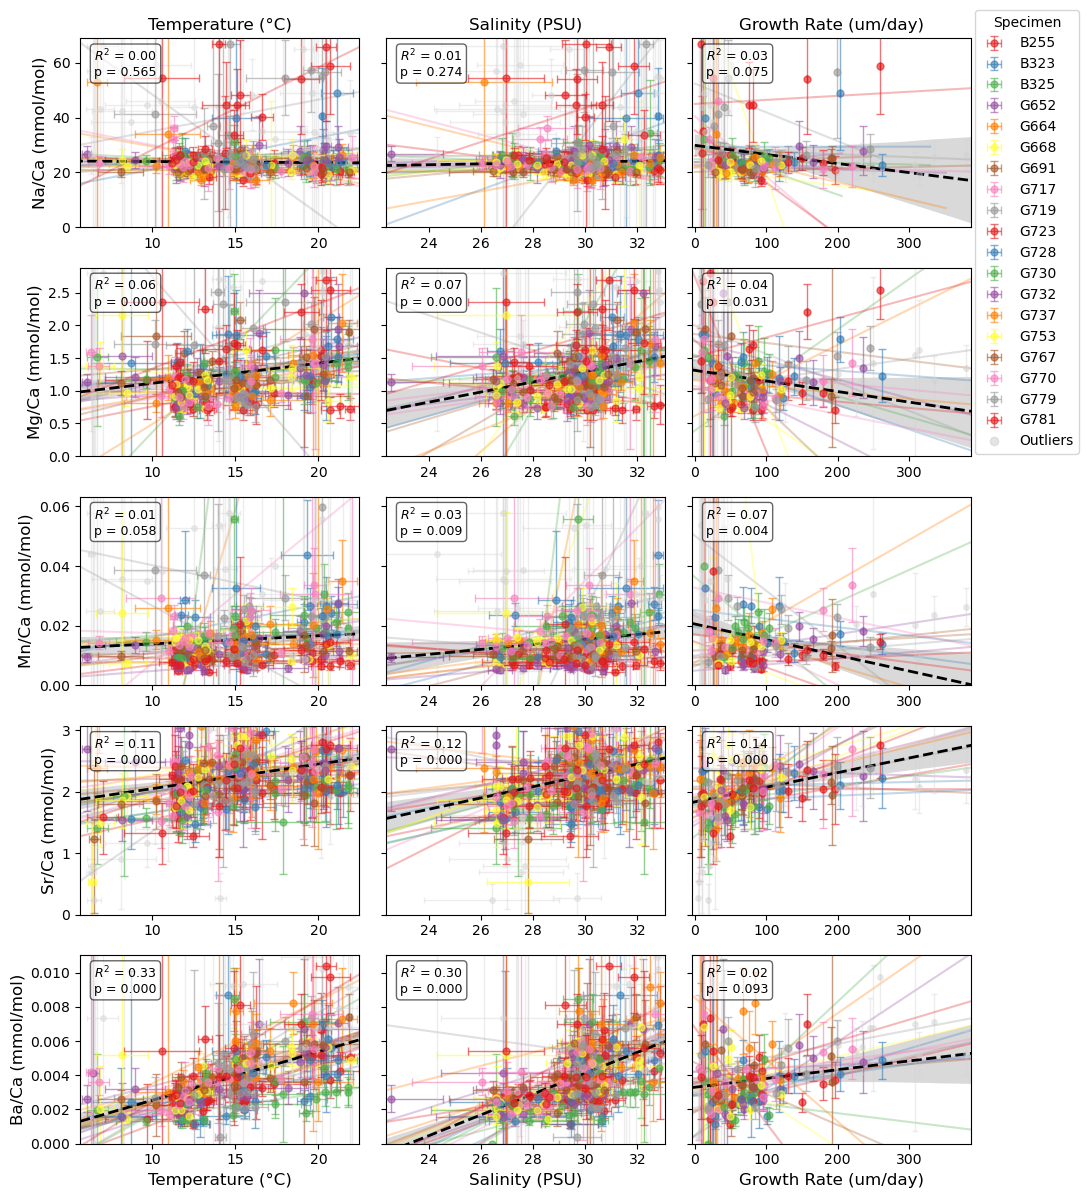

In [48]:
# Function to remove outliers based on the IQR method for both x and y (k = number of IQRs as benchmark)
def remove_outliers_iqr(df, x_col, y_col, k=1.5):
    """Remove outliers based on the IQR method for both x and y."""
    df = df[[x_col, y_col]].dropna()
    
    # X filtering
    Q1_x, Q3_x = df[x_col].quantile([0.25, 0.75])
    IQR_x = Q3_x - Q1_x
    x_mask = (df[x_col] >= Q1_x - k * IQR_x) & (df[x_col] <= Q3_x + k * IQR_x)

    # Y filtering
    Q1_y, Q3_y = df[y_col].quantile([0.25, 0.75])
    IQR_y = Q3_y - Q1_y
    y_mask = (df[y_col] >= Q1_y - k * IQR_y) & (df[y_col] <= Q3_y + k * IQR_y)

    # Combine masks
    return df[x_mask & y_mask]

# Mapping actual column names → display names
predictor_display_names = {
    'T_mean': 'Temperature (°C)',
    'S_mean': 'Salinity (PSU)',
    'growth_mean': 'Growth Rate (um/day)'
}

response_display_names = {
    'NaCa_mean': 'Na/Ca (mmol/mol)',
    'MgCa_mean': 'Mg/Ca (mmol/mol)',
    'MnCa_mean': 'Mn/Ca (mmol/mol)',
    'SrCa_mean': 'Sr/Ca (mmol/mol)',
    'BaCa_mean': 'Ba/Ca (mmol/mol)'
}

predictor_names = {
    'T_mean': 'T_sd',
    'S_mean': 'S_sd',
    'growth_mean': 'growth_sd'
}

response_names = {
    'NaCa_mean': 'NaCa_sd',
    'MgCa_mean': 'MgCa_sd',
    'MnCa_mean': 'MnCa_sd',
    'SrCa_mean': 'SrCa_sd',
    'BaCa_mean': 'BaCa_sd'
}

# Prepare data for pairwise scatter plots
predictors = list(predictor_names.keys())
responses = list(response_names.keys())

# Assign unique colors to each specimen
specimens = data_summary['specimen'].unique()
palette = sns.color_palette("Set1", n_colors=len(specimens))
specimen_colors = dict(zip(specimens, palette))

# Store regression stats
global_stats_lin_outliers = {}      # global regression stats
specimen_stats_lin_outliers = {}    # optional, not plotted

# Initialize the figure and axes for pairwise scatter plots
fig, axs = plt.subplots(len(responses), len(predictors), figsize=(10, 12), sharex='col', sharey='row')

for i, response in enumerate(responses):
    for j, predictor in enumerate(predictors):
        ax = axs[i, j]
        for specimen in specimens:
            df_subset_raw = data_summary[data_summary['specimen'] == specimen] # All data for the current specimen
            df_subset = remove_outliers_iqr(df_subset_raw, predictor, response) # Clean data
            # Plot regression line per specimen
            sns.regplot(
                x=predictor,
                y=response,
                data=df_subset,
                scatter=False,
                ax=ax,
                ci=None,
                color=specimen_colors[specimen],
                line_kws={"lw": 1.5, "alpha": 0.3},
                truncate=False
            )

            # Compute and store specimen-specific stats
            df_regs = df_subset.dropna(subset=[predictor, response])
            Xs = sm.add_constant(df_regs[predictor])
            ys = df_regs[response]
            if len(Xs) > 2:
                model_s = sm.OLS(ys, Xs).fit()
                specimen_stats_lin_outliers[(response, predictor, specimen)] = {
                    'r2': model_s.rsquared,
                    'p': model_s.pvalues[predictor]
                }
            else:
                specimen_stats_lin_outliers[(response, predictor, specimen)] = {
                    'r2': np.nan,
                    'p': np.nan
                }

            # Set color for the specimen
            color = specimen_colors[specimen]

            # Extract x, y, and error values for the current specimen
            # Separate raw and filtered data
            x_raw = df_subset_raw[predictor]
            y_raw = df_subset_raw[response]
            x_clean = df_subset[predictor]
            y_clean = df_subset[response]
            xerr = df_subset_raw[predictor_names[predictor]]
            yerr = df_subset_raw[response_names[response]]

            # Mask inliers
            inlier_mask = df_subset_raw.index.isin(df_subset.index)

            # Plot outliers in light gray
            ax.errorbar(x_raw[~inlier_mask],
                        y_raw[~inlier_mask],
                        xerr=xerr[~inlier_mask],
                        yerr=yerr[~inlier_mask],
                        fmt='o',
                        color='lightgray',
                        elinewidth=1,
                        alpha=0.4,
                        markersize=4,
                        capsize=2)

            # Plot inliers with color
            ax.errorbar(x_clean,
                        y_clean,
                        xerr=xerr[inlier_mask],
                        yerr=yerr[inlier_mask],
                        fmt='o',
                        color=color,
                        elinewidth=1,
                        alpha=0.6,
                        markersize=5,
                        capsize=3,
                        label=specimen if (i == 0 and j == 0) else None)  # only label once for legend
        # Plot global regression line (all specimens)
        df_reg = remove_outliers_iqr(data_summary, predictor, response)
        df_reg = df_reg[[predictor, response]].dropna()
        sns.regplot(
            x=predictor,
            y=response,
            data=df_reg,
            scatter=False,
            ax=ax,
            ci=95,
            color='black',
            line_kws={"lw": 2, "ls": "--"},
            truncate=False
        )

        # Calculate global regression stats (R², p)
        X = sm.add_constant(df_reg[predictor])
        y = df_reg[response]
        if len(df_reg) > 2:
            model = sm.OLS(y, X).fit()
            r2 = model.rsquared
            pval = model.pvalues[predictor]
        else:
            r2, pval = np.nan, np.nan

        global_stats_lin_outliers[(response, predictor)] = {'r2': r2, 'p': pval}

        # Annotate global stats
        stat_text = (f"$R^2$ = {r2:.2f}\np = {pval:.3f}"
             if not np.isnan(r2) and not np.isnan(pval)
             else "Insufficient data")
        ax.text(0.05, 0.95, stat_text,
                transform=ax.transAxes,
                va='top', ha='left',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.6))
        
        # Set labels and titles only for the first row and first column
        if i == 0:
            ax.set_title(predictor_display_names[predictor], fontsize=12)
        if j == 0:
            ax.set_ylabel(response_display_names[response], fontsize=12)
        else:
            ax.set_ylabel('')
        
        # Set limits for y-axis based on data and lower bound at 0
        ax.set_ylim(
            0,
            df_reg[response].max() + df_reg[response].std()
        )
        # Set limits for x-axis based on data
        ax.set_xlim(
            data_summary[predictor].min() - 0.1 * data_summary[predictor].std(),
            data_summary[predictor].max() + 0.1 * data_summary[predictor].std()
        )

        # Set x-axis tick labels on all plots
        ax.tick_params(axis='x', which='both', labelbottom=True)

        # Remove x-axis labels for all but the last row
        if i < len(responses) - 1:
            ax.set_xlabel('')
        else:
            ax.set_xlabel(predictor_display_names[predictor], fontsize=12)

# Add legend outside plot (only once)
handles, labels = axs[0, 0].get_legend_handles_labels()
# Add outlier legend handle (grey dot)
outlier_handle = Line2D([0], [0], marker='o', color='lightgray', label='Outliers',
                        linestyle='None', markersize=6, markerfacecolor='lightgray', alpha=0.6)
# Append to handles
handles.append(outlier_handle)
labels.append('Outliers')
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.1, 1.0), title="Specimen")

plt.tight_layout()
plt.show()

### Export regression results after outlier removal

In [49]:
# Convert the regression stats to a DataFrame for easier export
global_stats_df = pd.DataFrame.from_dict(global_stats_lin_outliers, orient='index').reset_index()
global_stats_df.columns = ['response', 'predictor', 'r2', 'p']
# Export regression results to CSV
global_stats_df.to_csv("Global_regression_stats_linear_outliers.csv", index=False)

# Export specimen-specific regression stats to CSV
specimen_stats_df = pd.DataFrame.from_dict(specimen_stats_lin_outliers, orient='index').reset_index()
specimen_stats_df.columns = ['response', 'predictor', 'specimen', 'r2', 'p']
# Export to CSV
specimen_stats_df.to_csv("Specimen_regression_stats_linear_outliers.csv", index=False)

### Pairwise scatterplots with log-transformed response variables

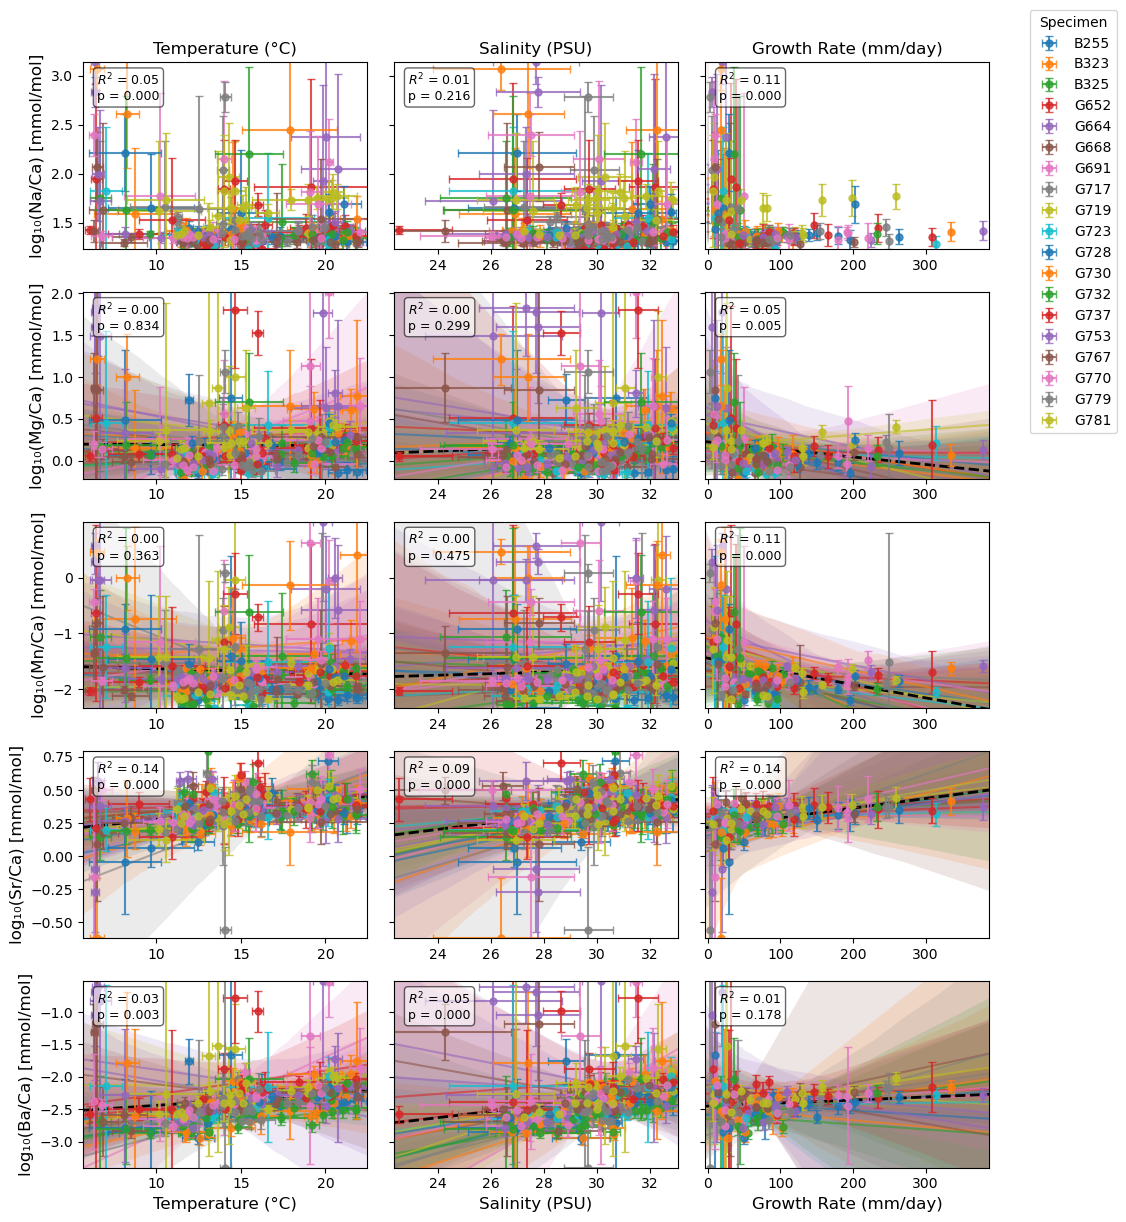

In [50]:
# Mappings and setup
predictor_errors = {
    'T_mean': 'T_sd',
    'S_mean': 'S_sd',
    'growth_mean': 'growth_sd'
}

response_errors = {
    'NaCa_mean': 'NaCa_sd',
    'MgCa_mean': 'MgCa_sd',
    'MnCa_mean': 'MnCa_sd',
    'SrCa_mean': 'SrCa_sd',
    'BaCa_mean': 'BaCa_sd'
}

predictor_display_names = {
    'T_mean': 'Temperature (°C)',
    'S_mean': 'Salinity (PSU)',
    'growth_mean': 'Growth Rate (mm/day)'
}

response_display_names = {
    'NaCa_mean': 'log₁₀(Na/Ca) [mmol/mol]',
    'MgCa_mean': 'log₁₀(Mg/Ca) [mmol/mol]',
    'MnCa_mean': 'log₁₀(Mn/Ca) [mmol/mol]',
    'SrCa_mean': 'log₁₀(Sr/Ca) [mmol/mol]',
    'BaCa_mean': 'log₁₀(Ba/Ca) [mmol/mol]'
}

predictors = list(predictor_errors.keys())
responses = list(response_errors.keys())
specimens = data_summary['specimen'].unique()
palette = sns.color_palette("tab10", len(specimens))
specimen_colors = dict(zip(specimens, palette))

# Create figure
fig, axs = plt.subplots(len(responses), len(predictors), figsize=(10, 12), sharex='col', sharey='row')

# Regression stats storage
global_stats_log_all = {}
specimen_stats_log_all = {}

# Iterate through plots
for i, response in enumerate(responses):
    for j, predictor in enumerate(predictors):
        ax = axs[i, j]

        # Drop non-positive or missing response values for log-transform
        df_valid = data_summary[[predictor, response, 'specimen',
                         predictor_errors[predictor], response_errors[response]]].copy()
        df_valid = df_valid[df_valid[response] > 0].dropna()

        # Log-transform the response
        df_valid[f'log_{response}'] = np.log10(df_valid[response])

        # Plot shaded regressions by specimen
        for specimen in specimens:
            df_s = df_valid[df_valid['specimen'] == specimen]
            if len(df_s) > 2:
                sns.regplot(
                    x=predictor, y=f'log_{response}', data=df_s,
                    scatter=False, ax=ax,
                    ci=95, color=specimen_colors[specimen],
                    line_kws={"lw": 1.5, "alpha": 0.6}, truncate=False
                )

                # Regression stats (specimen)
                Xs = sm.add_constant(df_s[predictor])
                ys = df_s[f'log_{response}']
                model_s = sm.OLS(ys, Xs).fit()
                specimen_stats_log_all[(response, predictor, specimen)] = {
                    'r2': model_s.rsquared,
                    'p': model_s.pvalues[predictor]
                }

        # Global regression (log-transformed response)
        if len(df_valid) > 2:
            X = sm.add_constant(df_valid[predictor])
            y = df_valid[f'log_{response}']
            model = sm.OLS(y, X).fit()
            r2 = model.rsquared
            pval = model.pvalues[predictor]

            global_stats_log_all[(response, predictor)] = {'r2': r2, 'p': pval}

            # Plot global regression
            sns.regplot(
                x=predictor, y=f'log_{response}', data=df_valid,
                scatter=False, ax=ax,
                ci=None, color='black',
                line_kws={"lw": 2, "ls": "--"}, truncate=False
            )
        else:
            r2, pval = np.nan, np.nan

        # Plot error bars (original response, but log y)
        for specimen in specimens:
            df_s = df_valid[df_valid['specimen'] == specimen]
            if not df_s.empty:
                y_log = np.log10(df_s[response])
                y_log_err = (df_s[response_errors[response]] / df_s[response]) / np.log(10)

                ax.errorbar(
                    df_s[predictor], y_log,
                    xerr=df_s[predictor_errors[predictor]],
                    yerr=y_log_err,
                    fmt='o', color=specimen_colors[specimen],
                    ecolor=specimen_colors[specimen],
                    alpha=0.8, capsize=3, markersize=5,
                    label=specimen if (i == 0 and j == 0) else None
                )

        # Annotate global regression stats
        stat_text = (f"$R^2$ = {r2:.2f}\np = {pval:.3f}"
                     if not np.isnan(r2) and not np.isnan(pval)
                     else "Insufficient data")

        ax.text(0.05, 0.95, stat_text,
                transform=ax.transAxes,
                va='top', ha='left',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.6))

        # Axis labels
        if i == 0:
            ax.set_title(predictor_display_names[predictor], fontsize=12)
        else:
            ax.set_title("")
        if j == 0:
            ax.set_ylabel(response_display_names[response], fontsize=12)
        else:
            ax.set_ylabel('')
        
        # Set limits for y-axis based on data rounded to next whole number
        ax.set_ylim(
            np.log10(data_summary[response][np.isfinite(data_summary[response]) & (data_summary[response] > 0)].min()),
            np.log10(data_summary[response][np.isfinite(data_summary[response]) & (data_summary[response] > 0)].max())
        )
        # Set limits for x-axis based on data
        ax.set_xlim(
            data_summary[predictor].min() - 0.1 * data_summary[predictor].std(),
            data_summary[predictor].max() + 0.1 * data_summary[predictor].std()
        )

        ax.tick_params(axis='x', which='both', labelbottom=True)

        # Remove x-axis labels for all but the last row
        if i < len(responses) - 1:
            ax.set_xlabel('')
        else:
            ax.set_xlabel(predictor_display_names[predictor], fontsize=12)

# Legend
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Specimen", loc='upper right', bbox_to_anchor=(1.12, 1.02))

plt.tight_layout()
plt.show()

### Export regression results after log conversion

In [51]:
# Convert the regression stats to a DataFrame for easier export
global_stats_df = pd.DataFrame.from_dict(global_stats_log_all, orient='index').reset_index()
global_stats_df.columns = ['response', 'predictor', 'r2', 'p']
# Export regression results to CSV
global_stats_df.to_csv("Global_regression_stats_log_all.csv", index=False)

# Export specimen-specific regression stats to CSV
specimen_stats_df = pd.DataFrame.from_dict(specimen_stats_log_all, orient='index').reset_index()
specimen_stats_df.columns = ['response', 'predictor', 'specimen', 'r2', 'p']
# Export to CSV
specimen_stats_df.to_csv("Specimen_regression_stats_log_all.csv", index=False)

## Linear regression models

### Linear regressions of all elements based on summary data

In [37]:
# Set up a multiple regression model using statsmodels
# Using elemental ratios as outcome variable and growth rate, temperature, and salinity as predictors

# Define the outcome variables
outcome_vars = ['NaCa_mean', 'MgCa_mean', 'MnCa_mean', 'SrCa_mean', 'BaCa_mean']
predictors = ['growth_mean', 'T_mean', 'S_mean']

# Initialize an empty list
results_list_summarized = []

for element in outcome_vars:
    # Prepare the data for regression
    X = data_summary[predictors].dropna()
    y = data_summary[element]
    
    # Combine the predictors and outcome variable
    data_regression = pd.concat([X, y], axis=1).dropna()
    X = data_regression[predictors]
    y = data_regression[element]

    # Add a constant to the predictors
    X = sm.add_constant(X)
    
    # Fit the regression model
    model = sm.OLS(y, X).fit()

    # Inside your loop
    results_list_summarized.append({
        'Element': element,
        'GR_slope': model.params.iloc[1],
        'T_slope': model.params.iloc[2],
        'S_slope': model.params.iloc[3],
        'GR_slope_norm': model.params['growth_mean'] / y.mean(),
        'T_slope_norm': model.params['T_mean'] / y.mean(),
        'S_slope_norm': model.params['S_mean'] / y.mean(),
        'Intercept': model.params.iloc[0],
        'R_squared': model.rsquared,
        'P_value': model.pvalues.iloc[1],
        'Std_err': model.bse.iloc[1],
        'RSE': model.bse.iloc[1] / y.mean(),
    })

# After the loop, create DataFrame
regression_results_summarized = pd.DataFrame(results_list_summarized)

# Display the regression results
print(regression_results_summarized)

     Element  GR_slope    T_slope    S_slope  GR_slope_norm  T_slope_norm  \
0  NaCa_mean -0.031281 -18.793518  19.982320      -0.000501     -0.301112   
1  MgCa_mean  0.003297  -0.786180   1.013509       0.001429     -0.340679   
2  MnCa_mean -0.000018  -0.048726   0.052615      -0.000170     -0.463532   
3  SrCa_mean  0.001141   0.041615   0.038447       0.000578      0.021083   
4  BaCa_mean  0.000027  -0.002574   0.003706       0.004138     -0.394532   

   S_slope_norm   Intercept  R_squared   P_value   Std_err       RSE  
0      0.320159 -250.474304   0.106927  0.884970  0.215848  0.003458  
1      0.439188  -16.438454   0.098572  0.679999  0.007978  0.003457  
2      0.500530   -0.735380   0.098123  0.975095  0.000571  0.005434  
3      0.019479    0.123054   0.409549  0.015164  0.000464  0.000235  
4      0.567944   -0.067708   0.081763  0.288076  0.000025  0.003881  


### Plot effect sizes of predictors

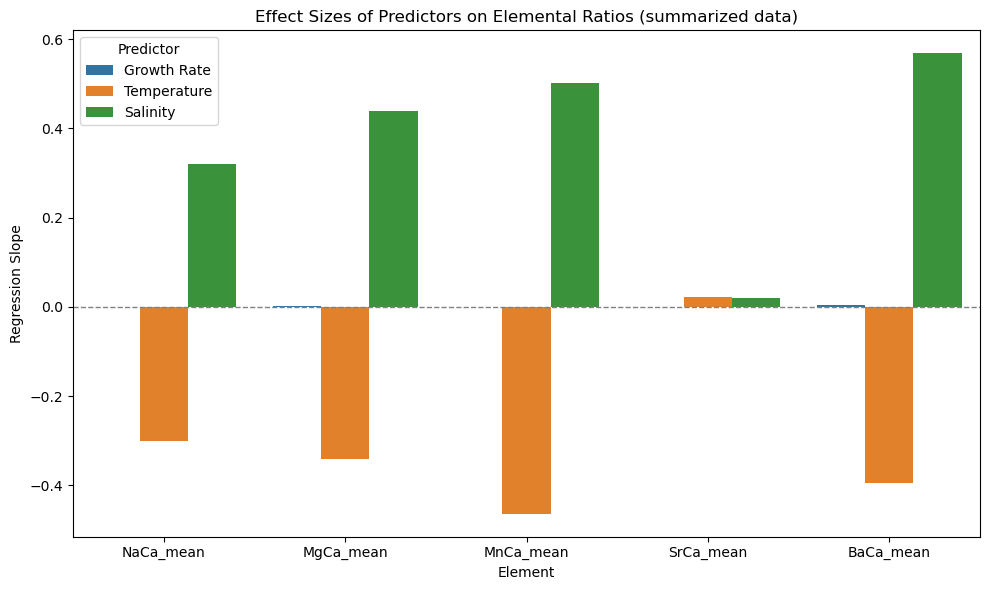

In [38]:
# Reshape the regression results to long format
effect_sizes_summarized = regression_results_summarized.melt(
    id_vars='Element',
    value_vars=['GR_slope_norm', 'T_slope_norm', 'S_slope_norm'],
    var_name='Predictor',
    value_name='EffectSize'
)

# Optional: rename predictors for clarity
effect_sizes_summarized['Predictor'] = effect_sizes_summarized['Predictor'].map({
    'GR_slope_norm': 'Growth Rate',
    'T_slope_norm': 'Temperature',
    'S_slope_norm': 'Salinity'
})

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=effect_sizes_summarized, x='Element', y='EffectSize', hue='Predictor')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Effect Sizes of Predictors on Elemental Ratios (summarized data)')
plt.ylabel('Regression Slope')
plt.tight_layout()
plt.legend(title='Predictor')
plt.show()

### Linear regressions of all elements based on full data

In [39]:
# Set up a multiple regression model using statsmodels
# Using elemental ratios as outcome variable and growth rate, temperature, and salinity as predictors

# Define the outcome variables
outcome_vars = ['23Na/43Ca', '25Mg/43Ca', '55Mn/43Ca', '88Sr/43Ca', '138Ba/43Ca']
predictors = ['interval_growth_rate_centered', 'T', 'S']

# Initialize an empty list
results_list_all = []

for element in outcome_vars:
    # Prepare the data for regression
    X = all_data[predictors].dropna()
    y = all_data[element]
    
    # Combine the predictors and outcome variable
    data_regression = pd.concat([X, y], axis=1).dropna()
    X = data_regression[predictors]
    y = data_regression[element]

    # Add a constant to the predictors
    X = sm.add_constant(X)
    
    # Fit the regression model
    model = sm.OLS(y, X).fit()

    # Inside your loop
    results_list_all.append({
        'Element': element,
        'GR_slope': model.params.iloc[1],
        'T_slope': model.params.iloc[2],
        'S_slope': model.params.iloc[3],
        'GR_slope_norm': model.params.iloc[1] / y.mean(),
        'T_slope_norm': model.params.iloc[2] / y.mean(),
        'S_slope_norm': model.params.iloc[3] / y.mean(),
        'Intercept': model.params.iloc[0],
        'R_squared': model.rsquared,
        'P_value': model.pvalues.iloc[1],
        'Std_err': model.bse.iloc[1],
        'RSE': model.bse.iloc[1] / y.mean(),
    })

# After the loop, create DataFrame
regression_results_all = pd.DataFrame(results_list_all)

# Display the regression results
print(regression_results_all)

      Element  GR_slope   T_slope   S_slope  GR_slope_norm  T_slope_norm  \
0   23Na/43Ca -0.042143 -2.821434  1.647005      -0.001228     -0.082241   
1   25Mg/43Ca -0.000582 -0.061751  0.096011      -0.000402     -0.042615   
2   55Mn/43Ca -0.000096 -0.007041  0.003993      -0.002699     -0.198354   
3   88Sr/43Ca  0.000947  0.021752  0.037637       0.000446      0.010247   
4  138Ba/43Ca  0.000006 -0.000119  0.000357       0.001366     -0.025207   

   S_slope_norm  Intercept  R_squared        P_value       Std_err       RSE  
0      0.048008  36.680580   0.018105  5.830148e-147  1.631911e-03  0.000048  
1      0.066259  -0.346222   0.002688   1.242167e-13  7.849261e-05  0.000054  
2      0.112499   0.043630   0.016030  9.256620e-113  4.244783e-06  0.000120  
3      0.017730   0.507487   0.095510   0.000000e+00  1.067483e-05  0.000005  
4      0.075566  -0.004951   0.001630   4.290816e-98  3.072822e-07  0.000065  


### Plot effect sizes of predictors

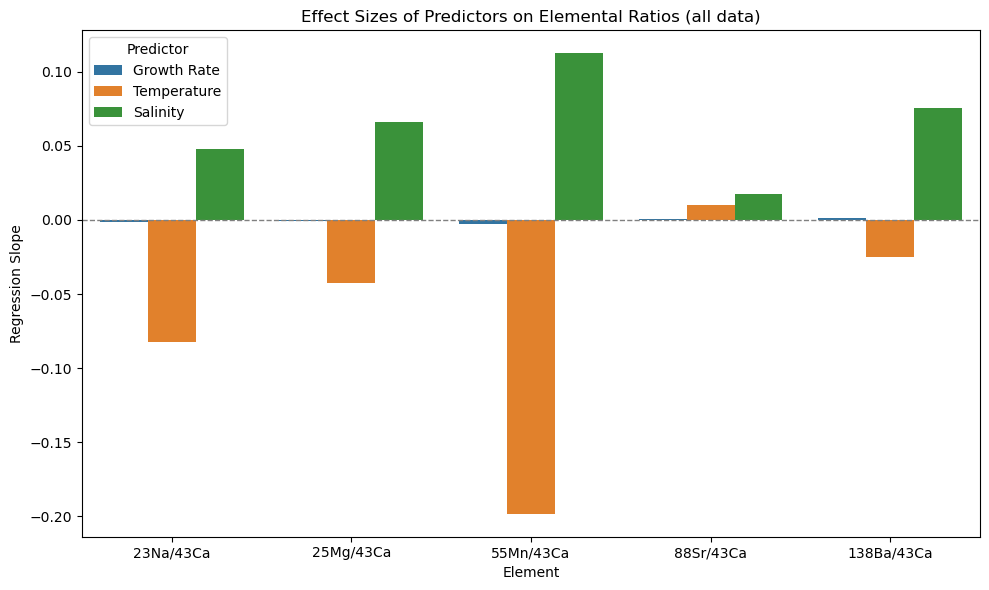

In [40]:
# TO DO: Add uncertainty estimates for the slopes

# Reshape the regression results to long format
effect_sizes_all = regression_results_all.melt(
    id_vars='Element',
    value_vars=['GR_slope_norm', 'T_slope_norm', 'S_slope_norm'],
    var_name='Predictor',
    value_name='EffectSize'
)

# Optional: rename predictors for clarity
effect_sizes_all['Predictor'] = effect_sizes_all['Predictor'].map({
    'GR_slope_norm': 'Growth Rate',
    'T_slope_norm': 'Temperature',
    'S_slope_norm': 'Salinity'
})

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=effect_sizes_all, x='Element', y='EffectSize', hue='Predictor')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Effect Sizes of Predictors on Elemental Ratios (all data)')
plt.ylabel('Regression Slope')
plt.tight_layout()
plt.legend(title='Predictor')
plt.show()

## LASSO regression

In [ ]:
# CHECK!

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(data[['temperature', 'salinity', 'growth_rate']])
for response in ['Na/Ca', 'Mg/Ca', 'Mn/Ca', 'Sr/Ca', 'Ba/Ca']:
    y = data[response]
    model = LassoCV(cv=5).fit(X_scaled, y)
    print(f"{response} Lasso Coefficients: {dict(zip(['Temp','Salinity','Growth'], model.coef_))}")

## Stepwise variable selection with AIC criteria